In [ ]:
!pip install xgboost
!pip install tensorflow

### **Import required libraries**

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight



from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ignore the warning messages
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# read dataset from a Google Drive File

#file_link = 'https://drive.google.com/drive/folders/1uyMzD0EZL2ihtPbolORJBM35c3Mdmx5L?usp=sharing' # the file access must have to be Public
file_link = "https://drive.google.com/file/d/1CS44Nc2Lk2iuo8JdGWXChMi_HiAv0OUW/view?usp=sharing"
# get the id part of the file
id = file_link.split("/")[-2]
# print(id)

# creating a new link using the id so that we can easily read the csv file in pandas
new_link = f'https://drive.google.com/uc?id={id}'
print(new_link)
data = pd.read_csv(new_link)

# let's look at the first few instances
data.head()

https://drive.google.com/uc?id=1CS44Nc2Lk2iuo8JdGWXChMi_HiAv0OUW


NameError: name 'pd' is not defined

**EDA**

In [ ]:
data.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [ ]:
data.shape

(1888, 14)

In [ ]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1888 entries, 0 to 1887
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1888 non-null   int64  
 1   sex       1888 non-null   int64  
 2   cp        1888 non-null   int64  
 3   trestbps  1888 non-null   int64  
 4   chol      1888 non-null   int64  
 5   fbs       1888 non-null   int64  
 6   restecg   1888 non-null   int64  
 7   thalachh  1888 non-null   int64  
 8   exang     1888 non-null   int64  
 9   oldpeak   1888 non-null   float64
 10  slope     1888 non-null   int64  
 11  ca        1888 non-null   int64  
 12  thal      1888 non-null   int64  
 13  target    1888 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 206.6 KB


In [ ]:
data.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
count,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000,1888.000000
mean,54.354343,0.688559,1.279131,131.549258,246.855403,0.148305,0.597458,149.424258,0.331568,1.053761,1.421610,0.731462,2.662606,0.517479
std,9.081505,0.463205,1.280877,17.556985,51.609329,0.355496,0.638820,23.006153,0.470901,1.161344,0.619588,1.015735,1.249924,0.499827
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.750000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,241.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,276.000000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,4.000000,7.000000,1.000000


In [ ]:
data.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalachh,0
exang,0
oldpeak,0


In [ ]:
# Check Unique Values
data.nunique()

,0
age,41
sex,2
cp,5
trestbps,50
chol,152
fbs,2
restecg,3
thalachh,92
exang,2
oldpeak,40


In [ ]:
#check the cat and num column name
cat_cols = data.select_dtypes(include=['object']).columns.tolist()
num_cols = data.select_dtypes(include=np.number).columns.tolist()
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
[]
Numerical Variables:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']


target
1    977
0    911
Name: count, dtype: int64


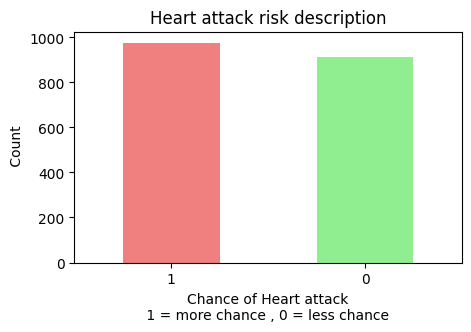

In [ ]:
# Visualize the distribution of the 'Survived' variable

print(data.value_counts('target'))

plt.figure(figsize=(5, 3))
data['target'].value_counts().plot(kind='bar', color=['lightcoral', 'lightgreen'])
plt.title('Heart attack risk description')
plt.xlabel("Chance of Heart attack\n 1 = more chance , 0 = less chance ")

plt.ylabel(' Count')
plt.xticks(rotation = 0)
plt.show()

In [ ]:
data['target'].value_counts()

,count
target,
1,977
0,911


In [ ]:
print(data.columns)
print(data.isnull().sum())

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalachh',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalachh    0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


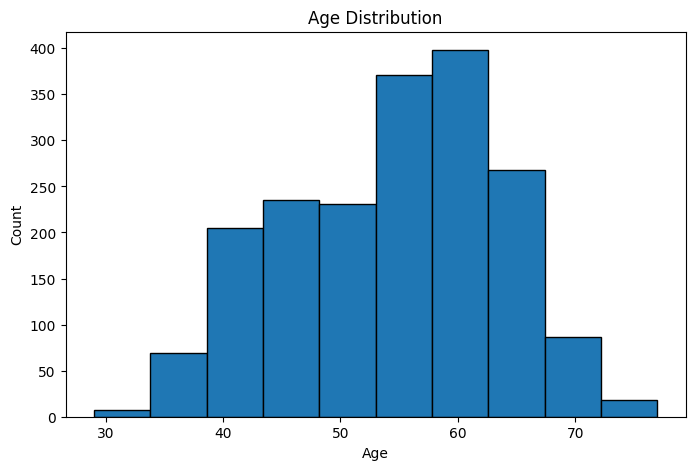

In [ ]:
# Visualize the distribution of 'Age' variable
plt.figure(figsize=(8, 5))
plt.hist(data['age'].dropna(), edgecolor='black')
# dropna eliminates the null/missing values but not in df
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

sex
1    1300
0     588
Name: count, dtype: int64


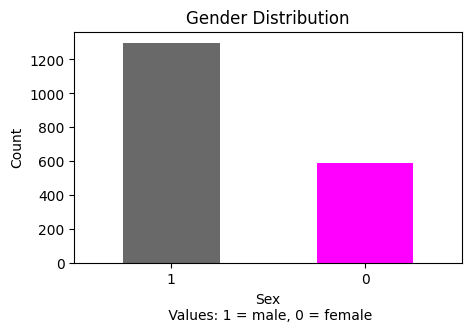

In [ ]:
# Visualize the distribution of 'Sex' variable
print(data.value_counts('sex'))

plt.figure(figsize=(5, 3))
data['sex'].value_counts().plot(kind='bar', color=['dimgray', 'magenta'])
plt.title('Gender Distribution')
plt.xlabel('Sex\n Values: 1 = male, 0 = female')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

cp
0    766
1    291
2    499
3    202
4    130
Name: count, dtype: int64


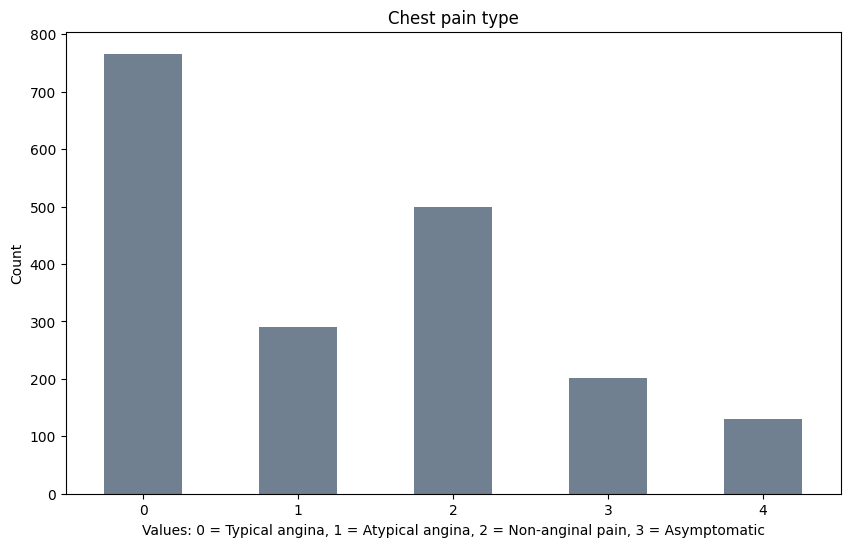

In [ ]:
# Visualize the distribution of 'cp' variable
print(data.value_counts('cp').sort_index())

plt.figure(figsize=(10, 6))
data['cp'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Chest pain type')
plt.xlabel('Values: 0 = Typical angina, 1 = Atypical angina, 2 = Non-anginal pain, 3 = Asymptomatic')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


fbs
0    1608
1     280
Name: count, dtype: int64


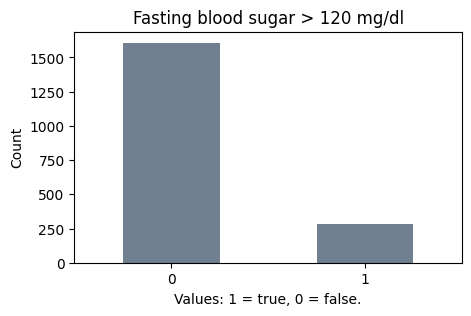

In [ ]:
# Visualize the distribution of 'fbs' variable
print(data.value_counts('fbs').sort_index())

plt.figure(figsize=(5, 3))
data['fbs'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Fasting blood sugar > 120 mg/dl')
plt.xlabel('Values: 1 = true, 0 = false.')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

restecg
0    918
1    812
2    158
Name: count, dtype: int64


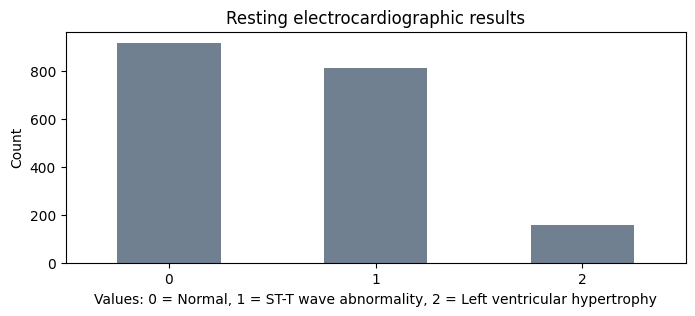

In [ ]:
# Visualize the distribution of 'restecg' variable
print(data.value_counts('restecg').sort_index())

plt.figure(figsize=(8, 3))
data['restecg'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Resting electrocardiographic results')
plt.xlabel('Values: 0 = Normal, 1 = ST-T wave abnormality, 2 = Left ventricular hypertrophy')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


exang
0    1262
1     626
Name: count, dtype: int64


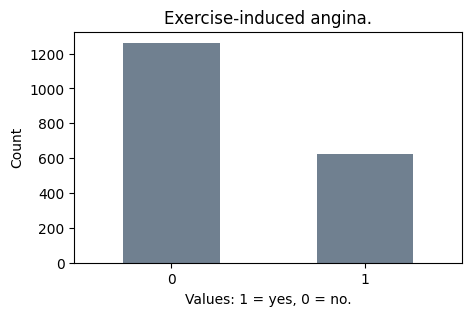

In [ ]:
# Visualize the distribution of 'exang' variable

print(data.value_counts('exang').sort_index())

plt.figure(figsize=(5, 3))
data['exang'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Exercise-induced angina.')
plt.xlabel('Values: 1 = yes, 0 = no.')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

slope
0    114
1    882
2    874
3     18
Name: count, dtype: int64


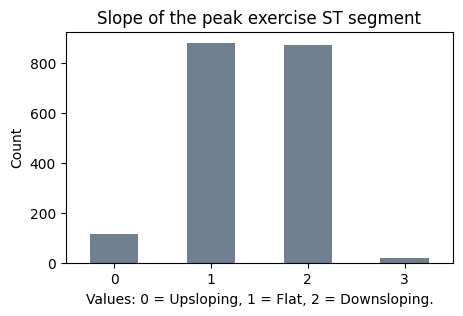

In [ ]:
# Visualize the distribution of 'slope' variable

print(data.value_counts('slope').sort_index())

plt.figure(figsize=(5, 3))
data['slope'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Slope of the peak exercise ST segment')
plt.xlabel('Values: 0 = Upsloping, 1 = Flat, 2 = Downsloping.')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
#slope: Slope of the peak exercise ST segment. Values: 0 = Upsloping, 1 = Flat, 2 = Downsloping.

ca
0    1084
1     410
2     239
3     127
4      28
Name: count, dtype: int64


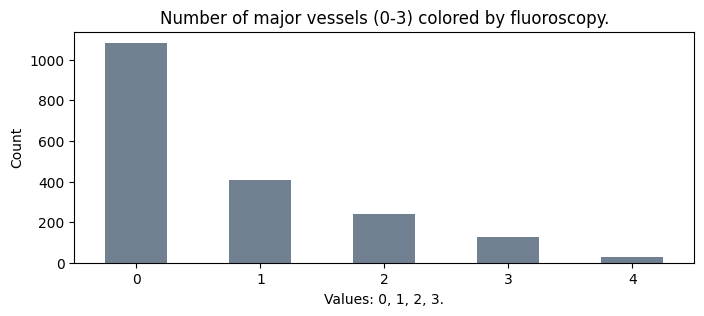

In [ ]:
# Visualize the distribution of 'ca' variable

print(data.value_counts('ca').sort_index())

plt.figure(figsize=(8, 3))
data['ca'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Number of major vessels (0-3) colored by fluoroscopy.')
plt.xlabel('Values: 0, 1, 2, 3.')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
#ca: Number of major vessels (0-3) colored by fluoroscopy. Values: 0, 1, 2, 3.

thal
0     11
1     96
2    874
3    788
6     14
7    105
Name: count, dtype: int64


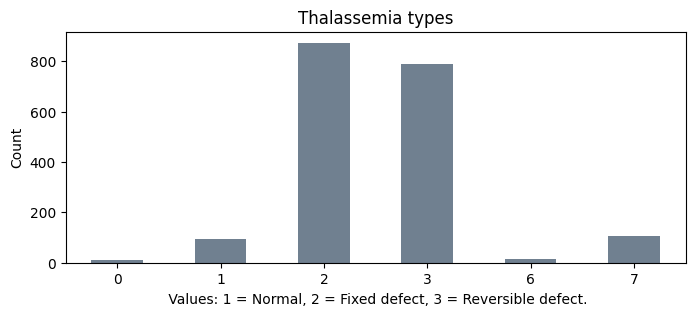

In [ ]:
# Visualize the distribution of 'thal' variable

print(data.value_counts('thal').sort_index())

plt.figure(figsize=(8, 3))
data['thal'].value_counts().sort_index().plot(kind='bar', color='slategrey')
plt.title('Thalassemia types')
plt.xlabel(' Values: 1 = Normal, 2 = Fixed defect, 3 = Reversible defect.')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()
#thal: Thalassemia types. Values: 1 = Normal, 2 = Fixed defect, 3 = Reversible defect.


               age       sex        cp  trestbps      chol       fbs  \
age       1.000000 -0.104266 -0.036207  0.271607  0.221379  0.119464   
sex      -0.104266  1.000000 -0.032933 -0.068685 -0.198892  0.032837   
cp       -0.036207 -0.032933  1.000000  0.025887 -0.037596  0.052189   
trestbps  0.271607 -0.068685  0.025887  1.000000  0.136976  0.171784   
chol      0.221379 -0.198892 -0.037596  0.136976  1.000000  0.024681   
fbs       0.119464  0.032837  0.052189  0.171784  0.024681  1.000000   
restecg  -0.059987 -0.031690  0.200863 -0.056821 -0.062365 -0.054344   
thalachh -0.392916 -0.053983  0.171463 -0.041222 -0.021208 -0.000829   
exang     0.092343  0.145680 -0.231718  0.067186  0.073496  0.035332   
oldpeak   0.205371  0.092515 -0.094668  0.196181  0.058111  0.000702   
slope    -0.121312 -0.020484  0.164810 -0.084387 -0.009180 -0.045836   
ca        0.283840  0.104863 -0.110988  0.098762  0.080456  0.132365   
thal      0.053396  0.168063  0.392841  0.054935  0.063576 -0.00

<Figure size 800x600 with 0 Axes>

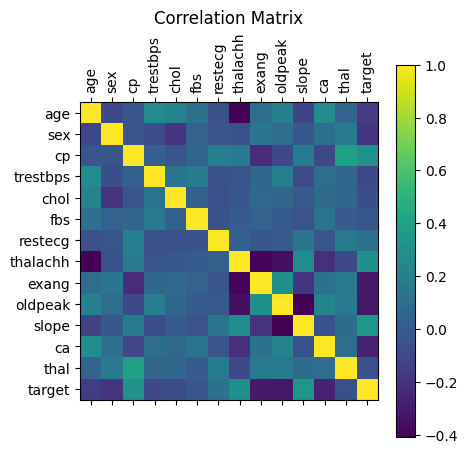

In [ ]:
# Correlation matrix plot
plt.figure(figsize=(8, 6))
correlation_matrix = data.corr(numeric_only=True)
print(correlation_matrix)
plt.matshow(correlation_matrix)
plt.title('Correlation Matrix')
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=90)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.colorbar()
plt.show()

<Axes: >

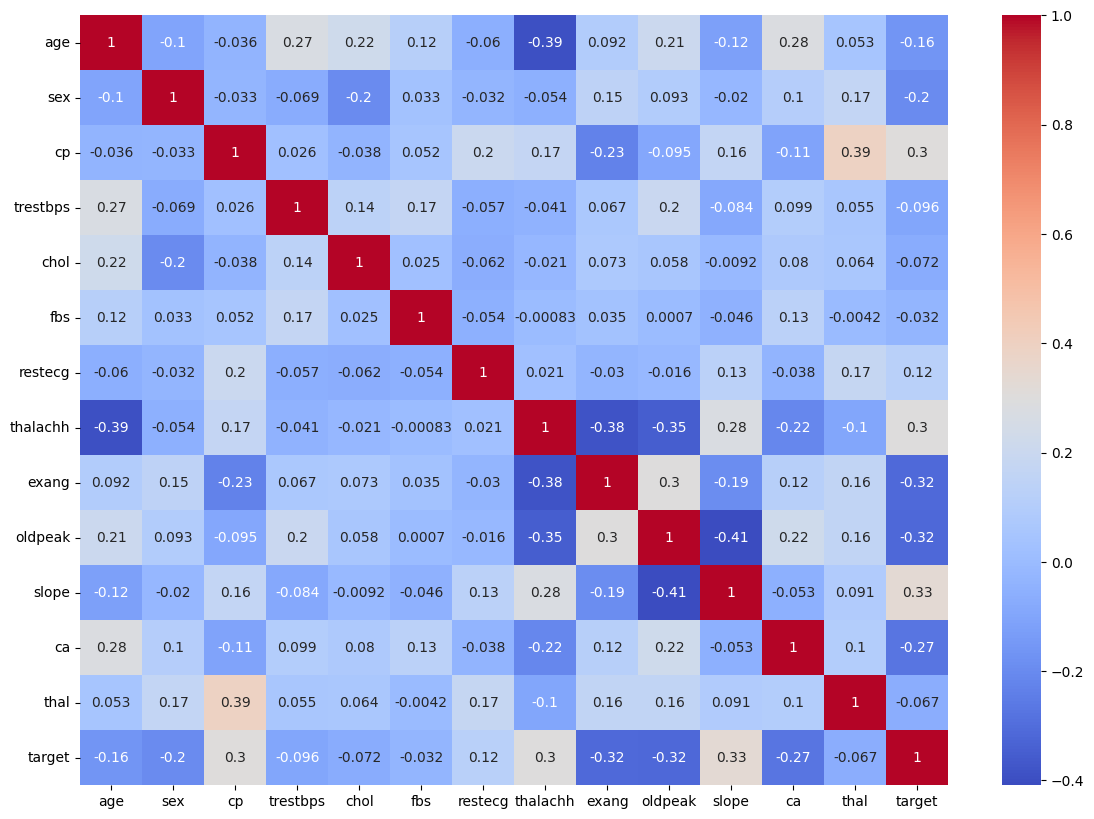

In [ ]:
import seaborn as sns
corr = data.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr,annot = True,cmap ="coolwarm")

# DATA **PROCESSING**

In [ ]:

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# import joblib


In [ ]:

X = data.drop('target', axis=1)
y = data['target']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


**MODEL**

In [ ]:

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42,verbosity=0)}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"{name} Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 0.7460
              precision    recall  f1-score   support

           0       0.78      0.66      0.71       182
           1       0.72      0.83      0.77       196

    accuracy                           0.75       378
   macro avg       0.75      0.74      0.74       378
weighted avg       0.75      0.75      0.74       378

Random Forest Accuracy: 0.9762
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       182
           1       0.97      0.98      0.98       196

    accuracy                           0.98       378
   macro avg       0.98      0.98      0.98       378
weighted avg       0.98      0.98      0.98       378

SVM Accuracy: 0.9233
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       182
           1       0.92      0.94      0.93       196

    accuracy                           0.92       378
   macro avg       0.92      0.92      

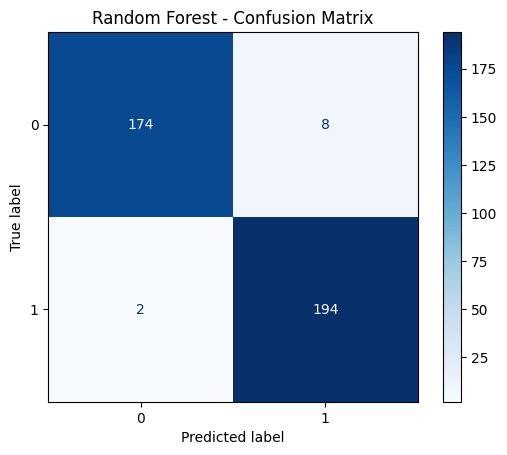

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

cm = confusion_matrix(y_test, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf.classes_)
disp.plot(cmap="Blues")
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [ ]:

# Logistic Regression tuning
log_reg = LogisticRegression(max_iter=1000)
param_grid_lr = {'C':[0.01,0.1,1,10], 'penalty':['l1','l2'], 'solver':['liblinear']}
grid_lr = GridSearchCV(log_reg, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)
print("Best Logistic Regression Params:", grid_lr.best_params_)

# Random Forest tuning
rf = RandomForestClassifier()
param_grid_rf = {'n_estimators':[100,200,500], 'max_depth':[None,5,10], 'min_samples_split':[2,5,10]}
grid_rf = GridSearchCV(rf, param_grid_rf, cv=5, scoring='accuracy')
grid_rf.fit(X_train, y_train)
print("Best Random Forest Params:", grid_rf.best_params_)

#Gradient boosting tuning

xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
param_grid_xgb = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0]
}

grid_xgb = GridSearchCV(xgb, param_grid_xgb, cv=5, scoring='accuracy')
grid_xgb.fit(X_train, y_train)

print("Best XGBoost Params:", grid_xgb.best_params_)




Best Logistic Regression Params: {'C': 0.1, 'penalty': 'l2', 'solver': 'liblinear'}
Best Random Forest Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


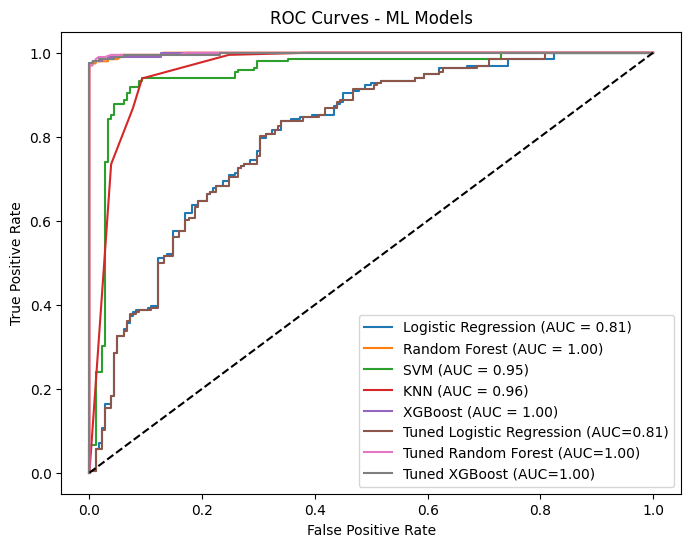

In [ ]:

plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc(fpr,tpr):.2f})")

y_prob = grid_lr.best_estimator_.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"Tuned Logistic Regression (AUC={auc(fpr,tpr):.2f})")

y_prob = grid_rf.best_estimator_.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"Tuned Random Forest (AUC={auc(fpr,tpr):.2f})")


y_prob = grid_xgb.best_estimator_.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f"Tuned XGBoost (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - ML Models")
plt.legend()
plt.show()


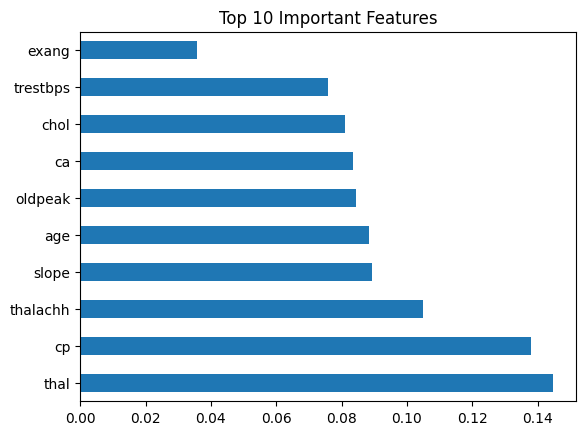

In [ ]:

importances = grid_rf.best_estimator_.feature_importances_
feat_importances = pd.Series(importances, index=data.drop('target',axis=1).columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Important Features")
plt.show()


In [ ]:

ann = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

ann.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = ann.fit(X_train, y_train, validation_data=(X_test,y_test), epochs=50, batch_size=32, verbose=1)


Epoch 1/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6012 - loss: 0.6418 - val_accuracy: 0.6772 - val_loss: 0.5771
Epoch 2/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7303 - loss: 0.5301 - val_accuracy: 0.7090 - val_loss: 0.5442
Epoch 3/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7666 - loss: 0.4760 - val_accuracy: 0.7487 - val_loss: 0.5140
Epoch 4/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7822 - loss: 0.4444 - val_accuracy: 0.7540 - val_loss: 0.4882
Epoch 5/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8007 - loss: 0.4366 - val_accuracy: 0.7646 - val_loss: 0.4663
Epoch 6/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8063 - loss: 0.3912 - val_accuracy: 0.7989 - val_loss: 0.4435
Epoch 7/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8163 - loss: 0.3805 - val_accuracy: 0.7910 - val_loss: 0.4240
Epoch 8/50
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8382 - loss: 0.3607 - val_accuracy: 0.8069 - val_loss:

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


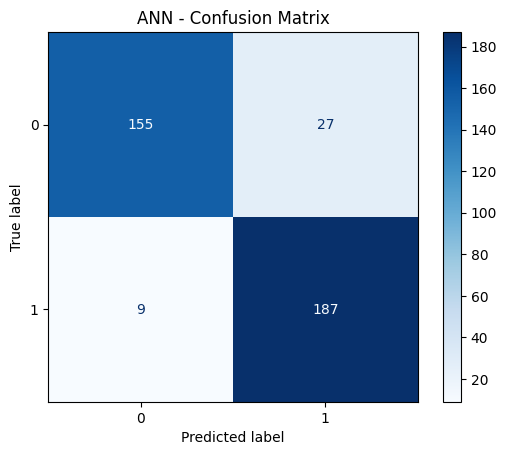

In [ ]:
y_pred_ann = (ann.predict(X_test) > 0.5).astype("int32")
cm = confusion_matrix(y_test, y_pred_ann)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1])
disp.plot(cmap="Blues")
plt.title("ANN - Confusion Matrix")
plt.show()

In [ ]:
# Predict probabilities
y_pred_probs = ann.predict(X_test)

# Convert to binary labels
y_pred = (y_pred_probs > 0.5).astype("int32")

# Print classification report (includes precision, recall, F1)
print(classification_report(y_test, y_pred))

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.95      0.85      0.90       182
           1       0.87      0.95      0.91       196

    accuracy                           0.90       378
   macro avg       0.91      0.90      0.90       378
weighted avg       0.91      0.90      0.90       378



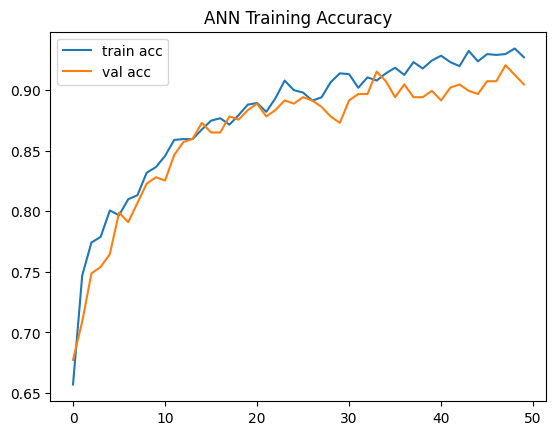

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


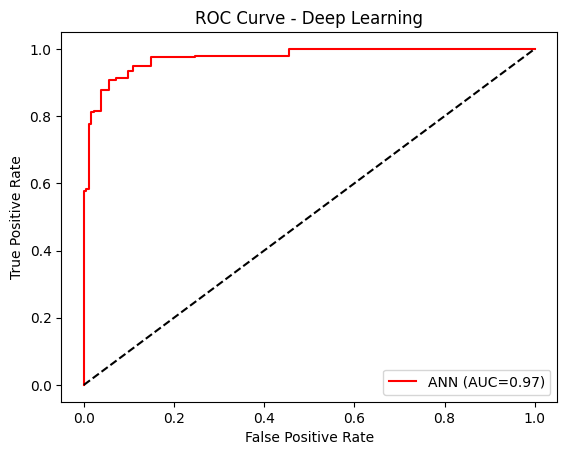

In [ ]:

plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.legend()
plt.title("ANN Training Accuracy")
plt.show()

y_prob_dl = ann.predict(X_test).ravel()
fpr, tpr, _ = roc_curve(y_test, y_prob_dl)
plt.plot(fpr, tpr, label=f"ANN (AUC={auc(fpr,tpr):.2f})", color='red')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Deep Learning")
plt.legend()
plt.show()


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

data = pd.read_csv(new_link)

target_col = "target"
if data[target_col].dtype == 'object':
    le = LabelEncoder()
    data[target_col] = le.fit_transform(data[target_col])

X = data.drop(target_col, axis=1)
y = data[target_col]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

log_reg = LogisticRegression(C=0.1, penalty='l2', solver='liblinear', max_iter=1000)
log_reg.fit(X_train, y_train)

# Random Forest with best params
rf = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_split=2, random_state=42
)
rf.fit(X_train, y_train)

# XGBoost with best params
xgb = XGBClassifier(
    learning_rate=0.1, max_depth=7, n_estimators=100,
    subsample=0.8, use_label_encoder=False, eval_metric='logloss', random_state=42
)
xgb.fit(X_train, y_train)


acc_lr = accuracy_score(y_test, log_reg.predict(X_test))
acc_rf = accuracy_score(y_test, rf.predict(X_test))
acc_xgb = accuracy_score(y_test, xgb.predict(X_test))

print("Logistic Regression (tuned) Accuracy:", acc_lr)
print("Random Forest (tuned) Accuracy:", acc_rf)
print("XGBoost (tuned) Accuracy:", acc_xgb)




Logistic Regression (tuned) Accuracy: 0.7486772486772487
Random Forest (tuned) Accuracy: 0.9761904761904762
XGBoost (tuned) Accuracy: 0.9708994708994709


In [ ]:
from sklearn.metrics import roc_auc_score
# Predictions
y_pred_lr = log_reg.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_xgb = xgb.predict(X_test)

# Probabilities for AUC
y_prob_lr = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

# Logistic Regression
print("\nLogistic Regression (tuned):")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("AUC:", roc_auc_score(y_test, y_prob_lr))
print(classification_report(y_test, y_pred_lr))

# Random Forest
print("\nRandom Forest (tuned):")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("AUC:", roc_auc_score(y_test, y_prob_rf))
print(classification_report(y_test, y_pred_rf))

# XGBoost
print("\nXGBoost (tuned):")
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("AUC:", roc_auc_score(y_test, y_prob_xgb))
print(classification_report(y_test, y_pred_xgb))



Logistic Regression (tuned):
Accuracy: 0.7486772486772487
AUC: 0.8057019511101144
              precision    recall  f1-score   support

           0       0.78      0.66      0.72       182
           1       0.72      0.83      0.77       196

    accuracy                           0.75       378
   macro avg       0.75      0.75      0.75       378
weighted avg       0.75      0.75      0.75       378


Random Forest (tuned):
Accuracy: 0.9761904761904762
AUC: 0.9989347387306571
              precision    recall  f1-score   support

           0       0.99      0.96      0.97       182
           1       0.97      0.99      0.98       196

    accuracy                           0.98       378
   macro avg       0.98      0.98      0.98       378
weighted avg       0.98      0.98      0.98       378


XGBoost (tuned):
Accuracy: 0.9708994708994709
AUC: 0.9981778425655976
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       182
      